In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor


# ============================================================
# Random seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)


# ============================================================
# Load data
# ============================================================

# data = pd.read_csv(
#     "../../../data/processed/model_df_next_mmse_blood.csv"
# )

data = pd.read_csv(
    "../../../data/processed/model_df_next_mmse3.csv"
)

print(data.shape)

df = data.copy()


(5538, 58)


#### 缺失資料

In [2]:
# ============================================================
# Missing value summary
# ============================================================

missing_summary = pd.DataFrame({
    "missing_count": data.isna().sum(),
    "missing_rate_pct": data.isna().mean() * 100
})

# 只保留有缺失值的欄位
missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
]

# 缺失比例由大到小排序
missing_summary = missing_summary.sort_values(
    "missing_rate_pct",
    ascending=False
)

# 百分比四捨五入
missing_summary["missing_rate_pct"] = (
    missing_summary["missing_rate_pct"]
    .round(2)
)

print("\n================ Missing Value Summary ================\n")
print(missing_summary)

print("\n有缺失值的欄位數：", len(missing_summary))
print("總欄位數：", data.shape[1])
print("總資料筆數：", data.shape[0])


================ Missing Value Summary ================

                              missing_count  missing_rate_pct
fasting_glucose_blood_date             1154             20.84
fasting_glucose_gap_days               1154             20.84
fasting_glucose                        1154             20.84
vldl_gap_days                          1153             20.82
vldl                                   1153             20.82
vldl_blood_date                        1153             20.82
casi_date                              1099             19.84
casi_attention                         1099             19.84
casi_mental_manipulation               1099             19.84
casi_abstraction                       1099             19.84
casi_short_term_memory                 1099             19.84
casi_total                             1099             19.84
casi_language                          1099             19.84
casi_drawing                           1099             19.84
casi_verbal_

### 處理日期並排序 / 建立 visit gap days欄位，代表每次MMSE量測日期的時間差距

In [3]:
df["visit_date"] = pd.to_datetime(
    df["visit_date"],
    errors="coerce"
)

df = df.sort_values(
    ["patient_id", "visit_date"]
).reset_index(drop=True)

df["visit_gap_days"] = (
    df.groupby("patient_id")["visit_date"]
    .diff()
    .dt.days
)
#第一次 visit 沒有上一筆，所以填 0
df["visit_gap_days"] = (
    df["visit_gap_days"]
    .fillna(0)
)
#因為天數可能非常大，所以做：log (1+gap)
df["visit_gap_log"] = np.log1p(
    df["visit_gap_days"].clip(lower=0)
)

In [4]:
target_history_features = [
    "mmse"
]

cdr_features = [
    "cdr_global",
    "cdr_memory",
    "cdr_orientation",
    "cdr_judgment",
    "cdr_community",
    "cdr_home_hobbies",
    "cdr_personal_care",
    "cdr_sob",
]

casi_features = [
    "casi_mental_manipulation",
    "casi_attention",
    "casi_orientation",
    "casi_long_term_memory",
    "casi_short_term_memory",
    "casi_abstraction",
    "casi_drawing",
    "casi_verbal_fluency",
    "casi_language",
    "casi_total",
    "days_since_casi",
    "has_recent_casi",
]

blood_features = [
    "hdl",
    "vldl",
    "ldl",
    "total_cholesterol",
    "triglyceride",
    "fasting_glucose",
    "hba1c",
]

blood_gap_features = [
    "hdl_gap_days",
    "vldl_gap_days",
    "ldl_gap_days",
    "total_cholesterol_gap_days",
    "triglyceride_gap_days",
    "fasting_glucose_gap_days",
    "hba1c_gap_days",
]

#這些 血液日期gap 可能很大，所以也做 log transform
for col in blood_gap_features:

    new_col = col + "_log"

    df[new_col] = np.log1p(
        df[col].clip(lower=0)
    )

blood_gap_log_features = [
    col + "_log"
    for col in blood_gap_features
]

#其他 clinical features
clinical_features = [
    "age_first_mmse",
    "education",
    "hypertension",
    "diabetes",
    "hyperlipidemia",
    "apoe4_count",
    "apoe_missing",
    "gender"
]

#時間
time_features = [
    "visit_gap_log"
]

#全部
feature_cols = (
    target_history_features
    + cdr_features
    + casi_features
    + blood_features
    + blood_gap_log_features
    + clinical_features
    + time_features
)

print("Feature 數量:", len(feature_cols))

for col in feature_cols:
    print(col)

Feature 數量: 44
mmse
cdr_global
cdr_memory
cdr_orientation
cdr_judgment
cdr_community
cdr_home_hobbies
cdr_personal_care
cdr_sob
casi_mental_manipulation
casi_attention
casi_orientation
casi_long_term_memory
casi_short_term_memory
casi_abstraction
casi_drawing
casi_verbal_fluency
casi_language
casi_total
days_since_casi
has_recent_casi
hdl
vldl
ldl
total_cholesterol
triglyceride
fasting_glucose
hba1c
hdl_gap_days_log
vldl_gap_days_log
ldl_gap_days_log
total_cholesterol_gap_days_log
triglyceride_gap_days_log
fasting_glucose_gap_days_log
hba1c_gap_days_log
age_first_mmse
education
hypertension
diabetes
hyperlipidemia
apoe4_count
apoe_missing
gender
visit_gap_log


In [5]:
visit_counts = (
    df.groupby("patient_id")
    .size()
)

visit_counts.describe()

count    1297.000000
mean        4.269854
std         3.984301
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        24.000000
dtype: float64

### 建立df_model資料集，保留至少兩次mmse visit的病人

In [6]:
valid_patient_ids = (
    visit_counts[
        visit_counts >= 2
    ]
    .index
)

df_model = df[
    df["patient_id"].isin(valid_patient_ids)
].copy()

print(
    "至少兩次 visit 的 patient:",
    df_model["patient_id"].nunique()
)

至少兩次 visit 的 patient: 915


In [7]:
patient_group_counts = (
    df_model[
        ["patient_id", "bio_category"]
    ]
    .drop_duplicates()
    ["bio_category"]
    .value_counts()
)

print(patient_group_counts)

bio_category
non-AD    439
AD        414
CU         62
Name: count, dtype: int64


In [8]:
missing_summary = pd.DataFrame({
    "missing_count": df_model.isnull().sum(),
    "missing_ratio": df_model.isnull().mean()
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0] \
    .sort_values("missing_count", ascending=False)

print(missing_summary)



                                missing_count  missing_ratio
casi_short_term_memory                    858       0.166408
casi_long_term_memory                     858       0.166408
casi_orientation                          858       0.166408
casi_attention                            858       0.166408
casi_mental_manipulation                  858       0.166408
casi_date                                 858       0.166408
casi_abstraction                          858       0.166408
casi_drawing                              858       0.166408
casi_language                             858       0.166408
casi_verbal_fluency                       858       0.166408
days_since_casi                           858       0.166408
casi_total                                858       0.166408
fasting_glucose                           831       0.161171
fasting_glucose_gap_days_log              831       0.161171
fasting_glucose_gap_days                  831       0.161171
fasting_glucose_blood_da

In [9]:
casi_missing_patient_count = (
    df_model.loc[df_model["casi_short_term_memory"].isnull(), "patient_id"]
    .nunique()
)

fasting_glucose_missing_patient_count = (
    df_model.loc[df_model["fasting_glucose"].isnull(), "patient_id"]
    .nunique()
)

print("casi_short_term_memory 缺失的 patient_id 數量：", casi_missing_patient_count)
print("fasting_glucose 缺失的 patient_id 數量：", fasting_glucose_missing_patient_count)

casi_short_term_memory 缺失的 patient_id 數量： 433
fasting_glucose 缺失的 patient_id 數量： 246


In [10]:
casi_all_missing_patient_count = (
    df_model.groupby("patient_id")["casi_short_term_memory"]
    .apply(lambda x: x.isnull().all())
    .sum()
)

fasting_glucose_all_missing_patient_count = (
    df_model.groupby("patient_id")["fasting_glucose"]
    .apply(lambda x: x.isnull().all())
    .sum()
)

print("所有紀錄的 casi_short_term_memory 都缺失的 patient_id 數量：", casi_all_missing_patient_count)
print("所有紀錄的 fasting_glucose 都缺失的 patient_id 數量：", fasting_glucose_all_missing_patient_count)

所有紀錄的 casi_short_term_memory 都缺失的 patient_id 數量： 139
所有紀錄的 fasting_glucose 都缺失的 patient_id 數量： 246


### 模型訓練

In [29]:
df["bio_category"]

0           AD
1           AD
2           AD
3           AD
4           AD
         ...  
5533        AD
5534    non-AD
5535    non-AD
5536        AD
5537        AD
Name: bio_category, Length: 5538, dtype: object

In [11]:
from sklearn.model_selection import train_test_split

GROUP = "CU"

group_df = df_model[
    df_model["bio_category"] == GROUP
].copy()

print(group_df.shape)

print(
    "Patients:",
    group_df["patient_id"].nunique()
)

#Patient-level train/validation/test split
patient_ids = (
    group_df["patient_id"]
    .drop_duplicates()
    .to_numpy()
)

train_ids, temp_ids = train_test_split(
    patient_ids,
    test_size=0.30,
    random_state=SEED
)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=SEED
)

print("Train patients:", len(train_ids))
print("Val patients:", len(val_ids))
print("Test patients:", len(test_ids))

print(
    set(train_ids)
    & set(val_ids)
)

print(
    set(train_ids)
    & set(test_ids)
)

(207, 67)
Patients: 62
Train patients: 43
Val patients: 9
Test patients: 10
set()
set()


In [12]:
train_df = group_df[
    group_df["patient_id"].isin(train_ids)
].copy()

val_df = group_df[
    group_df["patient_id"].isin(val_ids)
].copy()

test_df = group_df[
    group_df["patient_id"].isin(test_ids)
].copy()

### 建立missing indicators

In [13]:
train_df = group_df[
    group_df["patient_id"].isin(train_ids)
].copy()

val_df = group_df[
    group_df["patient_id"].isin(val_ids)
].copy()

test_df = group_df[
    group_df["patient_id"].isin(test_ids)
].copy()

missing_indicator_cols = []

for col in feature_cols:

    if train_df[col].isna().any():

        indicator_col = col + "_missing"

        train_df[indicator_col] = (
            train_df[col].isna().astype(int)
        )

        val_df[indicator_col] = (
            val_df[col].isna().astype(int)
        )

        test_df[indicator_col] = (
            test_df[col].isna().astype(int)
        )

        missing_indicator_cols.append(
            indicator_col
        )

In [14]:
print(
    "Missing indicators:",
    len(missing_indicator_cols)
)

Missing indicators: 25


### 缺值處理 (中位數填補)

In [15]:
imputer = SimpleImputer(
    strategy="median"
)

imputer.fit(
    train_df[feature_cols]
)

train_df[feature_cols] = imputer.transform(
    train_df[feature_cols]
)

val_df[feature_cols] = imputer.transform(
    val_df[feature_cols]
)

test_df[feature_cols] = imputer.transform(
    test_df[feature_cols]
)

In [16]:
final_feature_cols = (
    feature_cols
    + missing_indicator_cols
)

### StandardScaler

SVM 對特徵尺度非常敏感，因此 numeric features 使用 train set fit 的 StandardScaler。
Random Forest / XGBoost 對尺度不敏感，但為了讓三個模型共用完全相同的輸入資料，
這裡仍使用同一份標準化後的資料；missing indicator 保持 0/1，不做 scaling。

In [17]:
scaler = StandardScaler()
# missing indicator 不需要 scaling。所以只 scale 原始數值：
scaler.fit(
    train_df[feature_cols]
)

train_df[feature_cols] = scaler.transform(
    train_df[feature_cols]
)

val_df[feature_cols] = scaler.transform(
    val_df[feature_cols]
)

test_df[feature_cols] = scaler.transform(
    test_df[feature_cols]
)

### 將 longitudinal history 轉成固定長度特徵

SVM、Random Forest、XGBoost 無法直接處理每位病人長度不同的 sequence，
因此對「target 前的所有歷史 visits」建立固定長度 summary features：

- `last`：最近一次歷史 visit
- `mean`：歷史平均
- `std`：歷史標準差
- `min` / `max`：歷史範圍
- `history_n_visits`：target 前共有幾次 visit
- `history_span_days`：第一個歷史 visit 到最近歷史 visit 的天數

**Target 仍然是該病人的最後一次 MMSE，因此 test target 沒有被拿來建立輸入特徵。**

In [18]:
def create_tabular_history_features(
    data,
    feature_cols
):
    """
    將每位 patient 在 target visit 之前的 longitudinal history
    轉成固定長度向量，供 SVM / RF / XGBoost 使用。

    Target = 該 patient 最後一次 visit 的 MMSE
    History = 最後一次 visit 之前的所有 visits
    """

    X_rows = []
    y = []
    patient_ids = []

    for patient_id, patient_df in data.groupby("patient_id"):

        patient_df = (
            patient_df
            .sort_values("visit_date")
            .reset_index(drop=True)
        )

        # 至少要有 2 次 visit：
        # 前面 >= 1 次做 history，最後 1 次做 target
        if len(patient_df) < 2:
            continue

        history = patient_df.iloc[:-1].copy()
        target_visit = patient_df.iloc[-1]

        hist_values = history[feature_cols]

        row = {}

        # 最近一次歷史 visit
        last_values = hist_values.iloc[-1]
        for col in feature_cols:
            row[f"{col}_last"] = last_values[col]

        # 使用全部歷史 visit 的 summary
        means = hist_values.mean(axis=0)
        stds = hist_values.std(axis=0, ddof=0)
        mins = hist_values.min(axis=0)
        maxs = hist_values.max(axis=0)

        for col in feature_cols:
            row[f"{col}_mean"] = means[col]
            row[f"{col}_std"] = stds[col]
            row[f"{col}_min"] = mins[col]
            row[f"{col}_max"] = maxs[col]

        row["history_n_visits"] = len(history)

        if len(history) >= 2:
            row["history_span_days"] = (
                history["visit_date"].iloc[-1]
                - history["visit_date"].iloc[0]
            ).days
        else:
            row["history_span_days"] = 0

        X_rows.append(row)
        y.append(float(target_visit["mmse"]))
        patient_ids.append(patient_id)

    X = pd.DataFrame(X_rows)

    return (
        X,
        np.asarray(y, dtype=float),
        np.asarray(patient_ids)
    )


In [19]:
X_train, y_train, train_patient_ids = (
    create_tabular_history_features(
        train_df,
        final_feature_cols
    )
)

X_val, y_val, val_patient_ids = (
    create_tabular_history_features(
        val_df,
        final_feature_cols
    )
)

X_test, y_test, test_patient_ids = (
    create_tabular_history_features(
        test_df,
        final_feature_cols
    )
)

# 保證三個 split 欄位順序完全一致
X_val = X_val.reindex(columns=X_train.columns)
X_test = X_test.reindex(columns=X_train.columns)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("Train patients:", len(train_patient_ids))
print("Val patients  :", len(val_patient_ids))
print("Test patients :", len(test_patient_ids))


X_train: (43, 347)
X_val  : (9, 347)
X_test : (10, 347)
Train patients: 43
Val patients  : 9
Test patients : 10


### 模型與 validation tuning

三個模型都只用 validation set 選超參數，**test set 不參與選模**。
選好參數後，再使用 `train + validation` 重新 fit，最後只在 test set 評估一次。

In [20]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


def tune_on_validation(
    estimator_class,
    param_grid,
    X_train,
    y_train,
    X_val,
    y_val,
    fixed_params=None
):
    """
    使用 validation RMSE 選擇最佳超參數。
    """
    fixed_params = fixed_params or {}

    tuning_rows = []
    best_rmse = np.inf
    best_params = None

    for params in ParameterGrid(param_grid):

        model = estimator_class(
            **fixed_params,
            **params
        )

        model.fit(
            X_train,
            y_train
        )

        val_pred = model.predict(
            X_val
        )

        metrics = regression_metrics(
            y_val,
            val_pred
        )

        tuning_rows.append({
            **params,
            **metrics
        })

        if metrics["RMSE"] < best_rmse:
            best_rmse = metrics["RMSE"]
            best_params = params.copy()

    tuning_df = (
        pd.DataFrame(tuning_rows)
        .sort_values("RMSE")
        .reset_index(drop=True)
    )

    return best_params, tuning_df


### 1. SVM（SVR）

In [21]:
svm_param_grid = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.1, 0.5, 1.0],
    "gamma": ["scale", 0.01, 0.1]
}

best_svm_params, svm_tuning = tune_on_validation(
    estimator_class=SVR,
    param_grid=svm_param_grid,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    fixed_params={
        "kernel": "rbf"
    }
)

print("Best SVM params:")
print(best_svm_params)

display(
    svm_tuning.head(10)
)


Best SVM params:
{'C': 100, 'epsilon': 1.0, 'gamma': 'scale'}


,C,epsilon,gamma,MAE,RMSE,R2
0,100.0,1.0,scale,0.847563,1.061498,0.321159
1,100.0,0.1,0.01,0.771397,1.142107,0.214144
2,10.0,0.1,0.01,0.771397,1.142107,0.214144
3,100.0,0.5,scale,0.922524,1.150345,0.202766
4,10.0,1.0,scale,0.947262,1.173925,0.169747
5,10.0,0.5,0.01,0.862926,1.181604,0.158850
6,100.0,0.5,0.01,0.862926,1.181604,0.158850
7,1.0,0.5,0.01,0.865664,1.187167,0.150911
8,10.0,0.5,scale,0.835532,1.212827,0.113810
9,1.0,0.1,0.01,0.815062,1.214299,0.111657


### 2. Random Forest

In [22]:
rf_param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", 0.5]
}

best_rf_params, rf_tuning = tune_on_validation(
    estimator_class=RandomForestRegressor,
    param_grid=rf_param_grid,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    fixed_params={
        "random_state": SEED,
        "n_jobs": -1
    }
)

print("Best RF params:")
print(best_rf_params)

display(
    rf_tuning.head(10)
)


Best RF params:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 600}


,max_depth,max_features,min_samples_leaf,n_estimators,MAE,RMSE,R2
0,NaN,sqrt,1,600,0.828982,1.114443,0.251753
1,NaN,sqrt,1,300,0.837868,1.116762,0.248635
2,10.0,sqrt,1,600,0.832882,1.117909,0.247091
3,10.0,sqrt,1,300,0.841496,1.121032,0.242879
4,5.0,sqrt,1,600,0.842427,1.130755,0.229688
5,5.0,sqrt,1,300,0.866276,1.156037,0.194857
6,NaN,sqrt,3,600,0.847649,1.185559,0.153209
7,10.0,sqrt,3,600,0.847649,1.185559,0.153209
8,5.0,sqrt,3,600,0.849388,1.186459,0.151924
9,10.0,sqrt,3,300,0.840056,1.190042,0.146793


### 3. XGBoost

In [23]:
xgb_param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1.0, 5.0]
}

best_xgb_params, xgb_tuning = tune_on_validation(
    estimator_class=XGBRegressor,
    param_grid=xgb_param_grid,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    fixed_params={
        "objective": "reg:squarederror",
        "random_state": SEED,
        "n_jobs": -1,
        "verbosity": 0
    }
)

print("Best XGBoost params:")
print(best_xgb_params)

display(
    xgb_tuning.head(10)
)


Best XGBoost params:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 600, 'reg_lambda': 1.0, 'subsample': 0.8}


,colsample_bytree,learning_rate,max_depth,n_estimators,reg_lambda,subsample,MAE,RMSE,R2
0,0.8,0.05,4,600,1.0,0.8,0.976006,1.292886,-0.007047
1,0.8,0.05,4,300,1.0,0.8,0.975918,1.293090,-0.007365
2,1.0,0.05,4,600,1.0,0.8,0.981167,1.301494,-0.020502
3,1.0,0.05,4,300,1.0,0.8,0.980630,1.301542,-0.020577
4,1.0,0.03,4,300,1.0,1.0,0.958617,1.302735,-0.022450
5,0.8,0.03,4,300,1.0,0.8,1.018144,1.306388,-0.028190
6,0.8,0.03,4,600,1.0,0.8,1.010620,1.307820,-0.030446
7,0.8,0.03,2,300,5.0,0.8,1.022717,1.309640,-0.033317
8,0.8,0.03,4,300,1.0,1.0,0.949455,1.309658,-0.033345
9,1.0,0.03,4,600,1.0,1.0,0.965353,1.311487,-0.036234


### 使用最佳參數重新訓練，並在 test set 比較

Validation 已完成選模後，將 train + validation 合併重新訓練。
Test set 在這之前完全沒有參與 tuning。

In [24]:
X_trainval = pd.concat(
    [X_train, X_val],
    axis=0,
    ignore_index=True
)

y_trainval = np.concatenate(
    [y_train, y_val]
)


svm_model = SVR(
    kernel="rbf",
    **best_svm_params
)

rf_model = RandomForestRegressor(
    random_state=SEED,
    n_jobs=-1,
    **best_rf_params
)

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
    **best_xgb_params
)


models = {
    "SVM": svm_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

test_predictions = {}
result_rows = []

for model_name, model in models.items():

    model.fit(
        X_trainval,
        y_trainval
    )

    y_pred = model.predict(
        X_test
    )

    test_predictions[model_name] = y_pred

    metrics = regression_metrics(
        y_test,
        y_pred
    )

    result_rows.append({
        "Model": model_name,
        **metrics
    })


results_df = (
    pd.DataFrame(result_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(results_df)


,Model,MAE,RMSE,R2
0,Random Forest,0.597377,0.691448,-0.647619
1,XGBoost,0.613658,0.706556,-0.720407
2,SVM,0.958830,1.212843,-4.069294


In [25]:
# 每位 test patient 的實際值與三個模型預測值
prediction_df = pd.DataFrame({
    "patient_id": test_patient_ids,
    "y_true": y_test,
    "SVM_pred": test_predictions["SVM"],
    "RF_pred": test_predictions["Random Forest"],
    "XGBoost_pred": test_predictions["XGBoost"]
})

display(
    prediction_df.head()
)


,patient_id,y_true,SVM_pred,RF_pred,XGBoost_pred
0,196,1.245984,-0.332268,0.354671,0.151432
1,280,1.245984,0.629297,0.456668,0.641978
2,381,-0.144882,-2.928493,-0.824088,-0.563494
3,477,0.550551,-0.701124,0.290923,0.452935
4,639,0.550551,0.190371,0.261946,0.130980


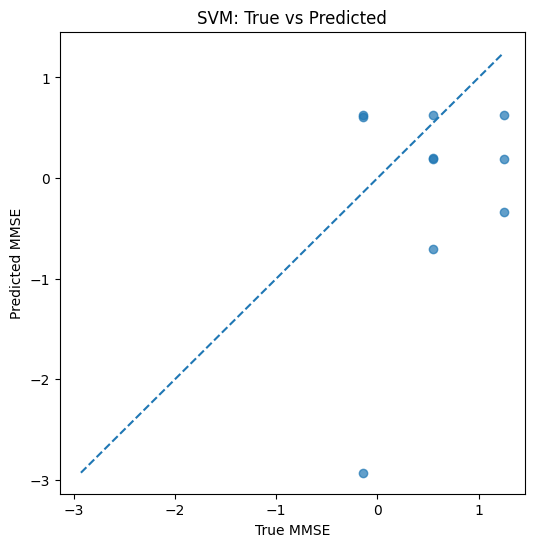

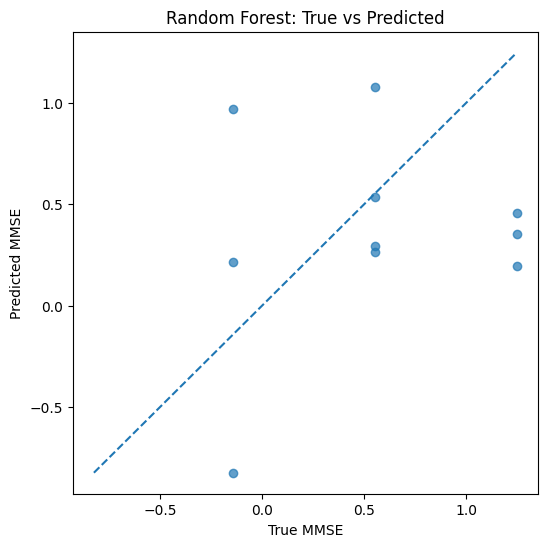

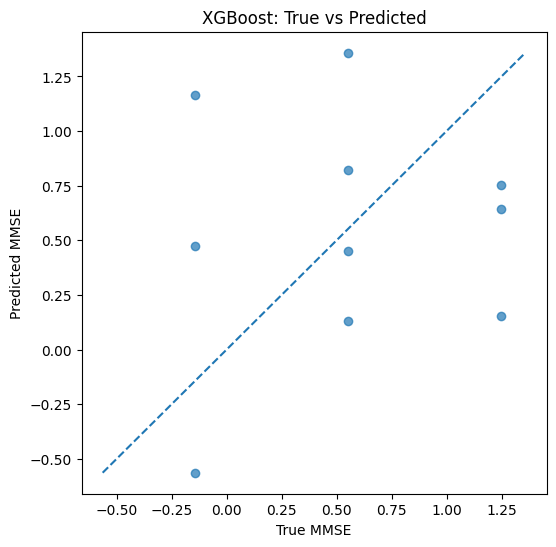

In [26]:
# Actual vs Predicted
for model_name, y_pred in test_predictions.items():

    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.7
    )

    lower = min(
        y_test.min(),
        y_pred.min()
    )
    upper = max(
        y_test.max(),
        y_pred.max()
    )

    plt.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--"
    )

    plt.xlabel("True MMSE")
    plt.ylabel("Predicted MMSE")
    plt.title(f"{model_name}: True vs Predicted")
    plt.show()


### Last-MMSE baseline

In [27]:
def last_mmse_baseline(
    data,
    patient_ids
):

    predictions = []
    targets = []

    for patient_id in patient_ids:

        patient_df = (
            data[
                data["patient_id"]
                == patient_id
            ]
            .sort_values(
                "visit_date"
            )
        )

        if len(patient_df) < 2:
            continue

        previous_mmse = (
            patient_df.iloc[-2]["mmse"]
        )

        target_mmse = (
            patient_df.iloc[-1]["mmse"]
        )

        predictions.append(
            previous_mmse
        )

        targets.append(
            target_mmse
        )

    return (
        np.array(predictions),
        np.array(targets)
    )

In [28]:
baseline_pred, baseline_true = (
    last_mmse_baseline(
        test_df,
        test_ids
    )
)

baseline_mae = mean_absolute_error(
    baseline_true,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_true,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    baseline_true,
    baseline_pred
)

print("Last-MMSE baseline")

print(
    f"MAE : {baseline_mae:.3f}"
)

print(
    f"RMSE: {baseline_rmse:.3f}"
)

print(
    f"R²  : {baseline_r2:.3f}"
)

Last-MMSE baseline
MAE : 0.626
RMSE: 0.852
R²  : -1.500
